In [1]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip3 install matplotlib seaborn scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cu118


In [2]:
modules = ['torch.', 'torchvision', 'sklearn', 'matplotlib.', 'seaborn','numpy','pandas']

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available()else "cpu")
print(f"Using: {device}")
if torch.cuda.is_available():
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f}GB")

Using: cuda
VRAM: 3.9GB


In [3]:
print(torch.__version__)

2.7.1+cu118


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,),(0.3081,))
])

train_data = datasets.MNIST('../datasets', train=True, download=True, transform=transform)
test_data = datasets.MNIST('../datasets', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [5]:

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28,128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128,10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


        

In [6]:

    model = SimpleNet().to(device)
    print(model)

SimpleNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [7]:
def train_epoch(model,loader, optimizer, criterion):
    model.train()
    total_loss=0
    correct=0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)
    

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

epochs = 5
for epoch in range(epochs):
    loss, acc = train_epoch(model, train_loader, optimizer, criterion)
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

Epoch 1: Loss=0.2292, Accuracy=0.9314
Epoch 2: Loss=0.1018, Accuracy=0.9687
Epoch 3: Loss=0.0730, Accuracy=0.9775
Epoch 4: Loss=0.0572, Accuracy=0.9817
Epoch 5: Loss=0.0462, Accuracy=0.9847


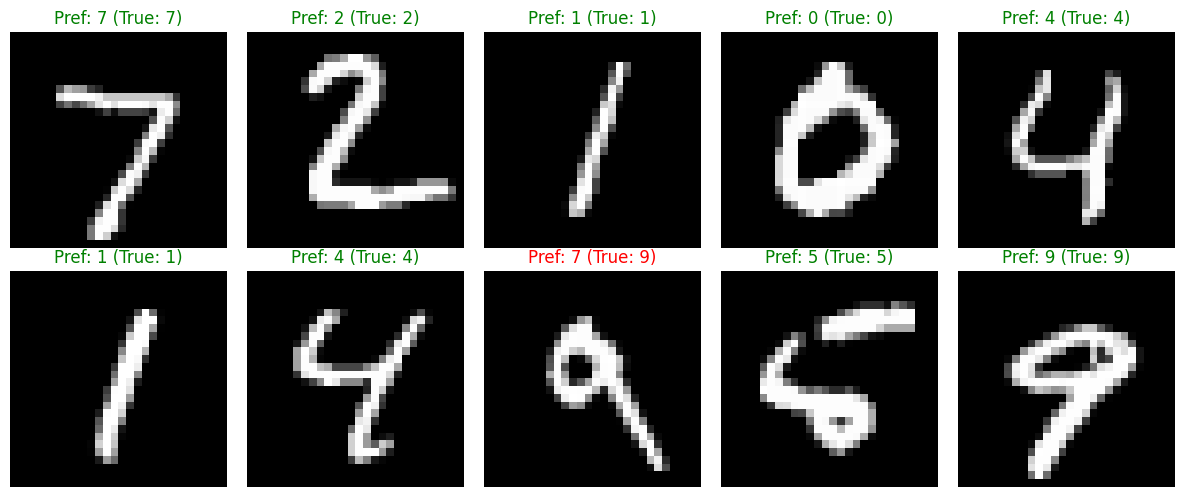

In [9]:
model.eval()
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    predictions = model(test_images).argmax(1).cpu()

fig, axes = plt.subplots(2,5, figsize=(12,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i].cpu().squeeze(), cmap='gray')
    pred = predictions[i].item()
    true = test_labels[i].item()
    color = 'green' if pred == true else 'red'
    color = 'green' if pred == true else 'red'
    ax.set_title(f'Pref: {pred} (True: {true})', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()